<a href="https://colab.research.google.com/github/ClaraWongChiaCi/STQD6324_Data_Management_Assignment_1/blob/main/P1662442_STQD6324_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Iris Classification using PySpark MLlib**

This project applies three machine learning models (Logistic Regression, Random Forest, and Decision Tree) on the Iris dataset via Spark MLlib. The main objective of this project is to compare the performances of these models and identify the best-performing model for Iris dataset.

## **1.0 Environment Setup**
PySpark is installed to enable Spark MLlib functionality in the Google Colab environment.

Spark session is then initialized as an entry point for working with Apache Spark. This would allow the use of Spark functionality and MLlib for distributed data processing and model training.

In [ ]:
#Install dependencies
!pip install pyspark

In [ ]:
#Spark Session Initialization
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder.appName("Iris").getOrCreate()
spark

## **2.0 Data Loading and Preprocessing**
Dataset is loaded via sklearn package and converted into Spark dataframe.

The label column is converted to DoubleType which is a floating-point number in Spark which ensures compatibility with Spark MLlib algorithms. PySpark MLlib requires a continuous numerical input that ensures stable and efficient model training (XXX).

The features are then combined using VectorAssembler where multiple columns are combined into a single vector column for MLlib processing (Gasparini, 2024).

In [ ]:
#Loading of Iris Dataset
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

The Iris dataset comprised of 150 samples along with four numerical features:
1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

Three classes of target variable are observed in the dataset:
1. Setosa
2. Versicolor
3. Virginica

In [ ]:
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df_iris['label'] = iris.target
df_iris.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [ ]:
#Convert to spark dataframe
spark_df = spark.createDataFrame(df_iris)
spark_df.show(5)

+-----------------+----------------+-----------------+----------------+-----+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|label|
+-----------------+----------------+-----------------+----------------+-----+
|              5.1|             3.5|              1.4|             0.2|    0|
|              4.9|             3.0|              1.4|             0.2|    0|
|              4.7|             3.2|              1.3|             0.2|    0|
|              4.6|             3.1|              1.5|             0.2|    0|
|              5.0|             3.6|              1.4|             0.2|    0|
+-----------------+----------------+-----------------+----------------+-----+
only showing top 5 rows


In [ ]:
#Converting of Label column to DoubleType
from pyspark.sql.functions import col
spark_df = spark_df.withColumn('label', col('label').cast('double'))

In [ ]:
spark_df.printSchema()

root
 |-- sepal length (cm): double (nullable = true)
 |-- sepal width (cm): double (nullable = true)
 |-- petal length (cm): double (nullable = true)
 |-- petal width (cm): double (nullable = true)
 |-- label: double (nullable = true)



In [ ]:
#To convert into a vector column using VectorAssembler
from pyspark.ml.feature import VectorAssembler

vector = VectorAssembler(inputCols=iris.feature_names, outputCol="features")
data = vector.transform(spark_df)
data = data.select("features", "label")

#To ensure randomSplit remains consistent across different model runs
data.cache()

data.show(5)

+-----------------+-----+
|         features|label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|  0.0|
|[4.9,3.0,1.4,0.2]|  0.0|
|[4.7,3.2,1.3,0.2]|  0.0|
|[4.6,3.1,1.5,0.2]|  0.0|
|[5.0,3.6,1.4,0.2]|  0.0|
+-----------------+-----+
only showing top 5 rows


## **3.0 Train-Test Split**
The dataset is split into 70% training and 30% testing using fixed random seed (eg. 42) to ensure reproducibility. 70/30 split is used rather than the conventional 80:20 split ratio was mainly to prevent overfitting and overoptimistic performance in the relatively small size iris dataset. This ensures that the model captures only sufficient information for generalization and avoid learning of noise. Test set that is too small might not cover the full range of scenarios which the model may encounter and potentially overlook hidden algorithmic bias. Hence, increasing test split to 30% allows higher chance for the hidden issues to surface during evaluation.

In [ ]:
#Splitting of data into train & test sets
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)

## **4.0 Model 1 - Logistic Regression**


In [ ]:
from pyspark.ml.classification import LogisticRegression
LR = LogisticRegression(featuresCol='features', labelCol='label')

In [ ]:
#Hyperparameter tuning
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
paramGrid = (ParamGridBuilder()
              .addGrid(LR.regParam, [0.001, 0.01, 0.1, 1.0])
              .addGrid(LR.elasticNetParam, [0.0, 0.5, 1.0])
              .build())

In [ ]:
#Cross-validation
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

cv_LR = CrossValidator(
    estimator=LR,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2, #Trains up to 2 models at once
    seed=42
)

In [ ]:
#model fitting
LRmodel = cv_LR.fit(train_data)

In [ ]:
#Extract parameters and average accuracy scores
LRparameters = LRmodel.getEstimatorParamMaps()
LRmetrics = LRmodel.avgMetrics

#zip together and sort to see the best performing combinations at the top
LRresults = sorted(zip(LRmetrics, LRparameters), key=lambda x: x[0], reverse=True)

print("Logistic Regression Hyperparameter Ranking (Best to Worst):")
for score, param_map in LRresults:
  param_details = {p.name: v for p, v in param_map.items()}
  print(f"Accuracy: {score:.4f} | Parameters: {param_details}")

Logistic Regression Hyperparameter Ranking (Best to Worst):
Accuracy: 0.9535 | Parameters: {'regParam': 0.01, 'elasticNetParam': 0.5}
Accuracy: 0.9452 | Parameters: {'regParam': 0.01, 'elasticNetParam': 0.0}
Accuracy: 0.9452 | Parameters: {'regParam': 0.01, 'elasticNetParam': 1.0}
Accuracy: 0.9402 | Parameters: {'regParam': 0.001, 'elasticNetParam': 0.0}
Accuracy: 0.9402 | Parameters: {'regParam': 0.001, 'elasticNetParam': 0.5}
Accuracy: 0.9402 | Parameters: {'regParam': 0.001, 'elasticNetParam': 1.0}
Accuracy: 0.9070 | Parameters: {'regParam': 0.1, 'elasticNetParam': 0.0}
Accuracy: 0.8987 | Parameters: {'regParam': 0.1, 'elasticNetParam': 0.5}
Accuracy: 0.8918 | Parameters: {'regParam': 0.1, 'elasticNetParam': 1.0}
Accuracy: 0.7774 | Parameters: {'regParam': 1.0, 'elasticNetParam': 0.0}
Accuracy: 0.3146 | Parameters: {'regParam': 1.0, 'elasticNetParam': 0.5}
Accuracy: 0.3146 | Parameters: {'regParam': 1.0, 'elasticNetParam': 1.0}


Hyperparameter tuning showed that Logistic Regression model performs best with low regularization. As regParam increased to more than 0.1, accuracy dropped significantly, indicating high penalty values were supressing important feature information, thus causing underfitting on the dataset.

In [ ]:
#Best model in Logistic Regression
import numpy as np
bestLR = LRmodel.bestModel

#Extract coefficient matrix
weights = bestLR.coefficientMatrix.toArray()

#Average absolute importance across 3 species
avgImportance = np.mean(np.abs(weights), axis=0)

#Map each value to its feature name
feature_LR = list(zip(iris.feature_names, avgImportance))
print("Logistic Regression Feature Importance:")
for feature, score in feature_LR:
  print(f"{feature}: {score:.4f}")

Logistic Regression Feature Importance:
sepal length (cm): 0.3272
sepal width (cm): 1.1647
petal length (cm): 0.9024
petal width (cm): 2.0868


## **5.0 Model 2 - Random Forest**

In [ ]:
#Random Forest
from pyspark.ml.classification import RandomForestClassifier
RF = RandomForestClassifier(featuresCol='features', labelCol='label', seed=42)
paramGrid_RF = (ParamGridBuilder()
              .addGrid(RF.numTrees, [10, 20, 50])
              .addGrid(RF.maxDepth, [5, 10])
              .addGrid(RF.impurity, ['gini', 'entropy'])
              .build())

In [ ]:
#Cross-validation and model fitting
cv_RF = CrossValidator(
    estimator=RF,
    estimatorParamMaps=paramGrid_RF,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4,
    seed=42
)
RFmodel = cv_RF.fit(train_data)

In [ ]:
#Extract parameters and average accuracy scores
RFparameters = RFmodel.getEstimatorParamMaps()
RFmetrics = RFmodel.avgMetrics

#zip together and sort to see the best performing combinations at the top
RFresults = sorted(zip(RFmetrics, RFparameters), key=lambda x: x[0], reverse=True)

print("Random Forest Hyperparameter Ranking (Best to Worst):")
for score, param_map in RFresults:
  params = {p.name: v for p, v in param_map.items()}
  print(f"Accuracy: {score:.4f} | Parameters: {params}")

Random Forest Hyperparameter Ranking (Best to Worst):
Accuracy: 0.9287 | Parameters: {'numTrees': 50, 'maxDepth': 5, 'impurity': 'gini'}
Accuracy: 0.9287 | Parameters: {'numTrees': 50, 'maxDepth': 5, 'impurity': 'entropy'}
Accuracy: 0.9287 | Parameters: {'numTrees': 50, 'maxDepth': 10, 'impurity': 'gini'}
Accuracy: 0.9287 | Parameters: {'numTrees': 50, 'maxDepth': 10, 'impurity': 'entropy'}
Accuracy: 0.9268 | Parameters: {'numTrees': 10, 'maxDepth': 5, 'impurity': 'gini'}
Accuracy: 0.9268 | Parameters: {'numTrees': 10, 'maxDepth': 5, 'impurity': 'entropy'}
Accuracy: 0.9268 | Parameters: {'numTrees': 10, 'maxDepth': 10, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'numTrees': 20, 'maxDepth': 5, 'impurity': 'gini'}
Accuracy: 0.9203 | Parameters: {'numTrees': 20, 'maxDepth': 5, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'numTrees': 20, 'maxDepth': 10, 'impurity': 'gini'}
Accuracy: 0.9153 | Parameters: {'numTrees': 10, 'maxDepth': 10, 'impurity': 'gini'}
Accuracy: 0.9

In [ ]:
#Best model from crossvalidator
bestRF = RFmodel.bestModel

#Feature importance scores
importance = bestRF.featureImportances

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_importance = list(zip(feature_names, importance))
print("Random Forest Feature Importance:")
for feature, score in feature_importance:
  print(f"{feature}: {score:.4f}")

Random Forest Feature Importance:
sepal_length: 0.1042
sepal_width: 0.0133
petal_length: 0.4327
petal_width: 0.4498


Petal width combining with petal_length, demonstrated approximately 90% importance (decision-making power/primary drivers of the classification), showed that barely needs to look at sepals to identify species.

Petals may be much better indicators of species than the sepals.

In [ ]:
#Get parameters used in the best model
print(f"Best Max Depth: {bestRF.getMaxDepth()}")
print(f"Best Number of Trees: {bestRF.getOrDefault('numTrees')}")
print(f"Best Impurity: {bestRF.getImpurity()}")

Best Max Depth: 5
Best Number of Trees: 50
Best Impurity: gini


## **6.0 Model 3 - Decision Tree**

In [ ]:
#Decision Tree
from pyspark.ml.classification import DecisionTreeClassifier
DT = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    seed=42
)
paramGrid_DT = (ParamGridBuilder()
                .addGrid(DT.maxDepth, [2, 5, 10])
                .addGrid(DT.maxBins, [10, 20, 30])
                .addGrid(DT.impurity, ['gini', 'entropy'])
                .build())

In [ ]:
#Cross Validation and training
cv_DT = CrossValidator(
    estimator=DT,
    estimatorParamMaps=paramGrid_DT,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)
DTmodel = cv_DT.fit(train_data)

In [ ]:
#Extract parameters and average accuracy scores
DTparameters = DTmodel.getEstimatorParamMaps()
DTmetrics = DTmodel.avgMetrics

#zip together and sort to see the best performing combinations at the top
DTresults = sorted(zip(DTmetrics, DTparameters), key=lambda x: x[0], reverse=True)

print("Decision Tree Hyperparameter Ranking (Best to Worst):")
for score, param_map in DTresults:
  params = {p.name: v for p, v in param_map.items()}
  print(f"Accuracy: {score:.4f} | Parameters: {params}")

Decision Tree Hyperparameter Ranking (Best to Worst):
Accuracy: 0.9268 | Parameters: {'maxDepth': 5, 'maxBins': 10, 'impurity': 'gini'}
Accuracy: 0.9268 | Parameters: {'maxDepth': 5, 'maxBins': 10, 'impurity': 'entropy'}
Accuracy: 0.9268 | Parameters: {'maxDepth': 10, 'maxBins': 10, 'impurity': 'gini'}
Accuracy: 0.9268 | Parameters: {'maxDepth': 10, 'maxBins': 10, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 5, 'maxBins': 20, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 5, 'maxBins': 30, 'impurity': 'gini'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 5, 'maxBins': 30, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 10, 'maxBins': 20, 'impurity': 'entropy'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 10, 'maxBins': 30, 'impurity': 'gini'}
Accuracy: 0.9203 | Parameters: {'maxDepth': 10, 'maxBins': 30, 'impurity': 'entropy'}
Accuracy: 0.9037 | Parameters: {'maxDepth': 5, 'maxBins': 20, 'impurity': 'gini'}
Accuracy: 0.9037 | Pa

Moving from maxDepth 5 to 10 did not improve accuracy, suggest that rules needed to identify an Iris flower are discovered at relatively shallow tree.

Smaller binning improved overall performance, suggest that splitting the values into too many buckets may hurt model's ability to generalise for small dataset like Iris.

In [ ]:
#Feature Importance for Decision Tree
bestDT = DTmodel.bestModel

importance_DT = bestDT.featureImportances
feature_DT = list(zip(feature_names, importance_DT))
print("Decision Tree Feature Importance:")
for feature, score in feature_DT:
  print(f"{feature}: {score:.4f}")

Decision Tree Feature Importance:
sepal_length: 0.0528
sepal_width: 0.0867
petal_length: 0.4456
petal_width: 0.4149


In [ ]:
#Best parameter for Decision Tree
print(f"Best Max Depth: {bestDT.getMaxDepth()}")
print(f"Best Max Bins: {bestDT.getMaxBins()}")
print(f"Best Impurity: {bestDT.getImpurity()}")

Best Max Depth: 5
Best Max Bins: 10
Best Impurity: gini


Decision Tree showed sepal width to be statistically insignificant for classification. Similar to Random Forest, petals dominate but with petal length taking lead over petal width. Matching of max depth and Gini impurity between DT and RF results, shows consistent models and stable data.

## **7.0 Evaluation Metrics**
The following metrics are used to evaluate the performance of each ML model conducted on the iris dataset, which include:
1. Accuracy
2. Precision
3. Recall
4. F1-score

In [ ]:
#Predictions and metric calculation for each model
import pandas as pd

#List to hold results
finalComparison = []

models = [
    ('Logistic Regression', LRmodel, LRmodel.avgMetrics),
    ('Random Forest', RFmodel, RFmodel.avgMetrics),
    ('Decision Tree', DTmodel, DTmodel.avgMetrics)
]

for name, fitted_model, cv_metrics in models:
  prediction = fitted_model.transform(test_data)

  #Evaluation metrics calculation
  row = {'Model': name}
  row['CV Accuracy'] = round(max(cv_metrics), 4)
  for metric in ['accuracy', 'weightedPrecision', 'weightedRecall', 'f1']:
    evaluator = MulticlassClassificationEvaluator(labelCol='label', metricName=metric)
    row[metric] = round(evaluator.evaluate(prediction), 4)

  finalComparison.append(row)

In [ ]:
#Evaluation metrics table
df_EM = pd.DataFrame(finalComparison)
df_EM.columns = ['Model', 'CV Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
df_EM

,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9535,0.9643,0.9694,0.9643,0.9647
1,Random Forest,0.9287,0.9821,0.9835,0.9821,0.9823
2,Decision Tree,0.9268,0.9643,0.9694,0.9643,0.9647


### Inferences on Train vs. Test Accuracy:

*   **Logistic Regression:**
    *   **Train Accuracy:** 0.9535
    *   **Test Accuracy:** 0.9643
    *   The test accuracy is slightly higher than the training accuracy, which is unusual but can happen due to the specific split of data, or if the test set is 'easier' to classify. Overall, the model shows good generalization and minimal signs of overfitting.

*   **Random Forest:**
    *   **Train Accuracy:** 0.9287
    *   **Test Accuracy:** 0.9821
    *   Similar to Logistic Regression, the Random Forest model shows a higher test accuracy than training accuracy. This indicates strong generalization performance on unseen data and no signs of overfitting. It is the best-performing model on the test set.

*   **Decision Tree:**
    *   **Train Accuracy:** 0.9268
    *   **Test Accuracy:** 0.9643
    *   Again, the test accuracy is higher than the training accuracy. This suggests that the Decision Tree model also generalizes well to new data, despite having slightly lower training accuracy compared to Logistic Regression. It performs similarly to Logistic Regression on the test set.

**General Observation:**
All three models show impressive performance, with test accuracies consistently higher than or very close to their training accuracies. This suggests that the models are generalizing well to unseen data and are not overfitting the training set. The Random Forest model stands out with the highest test accuracy, indicating it's the most robust for this dataset among the three.

## **8.0 Confusion Matrix**
Side-by-side comparison of confusion matrices for Random Forest and Logistic Regression to visualize how each model performed on the test set.

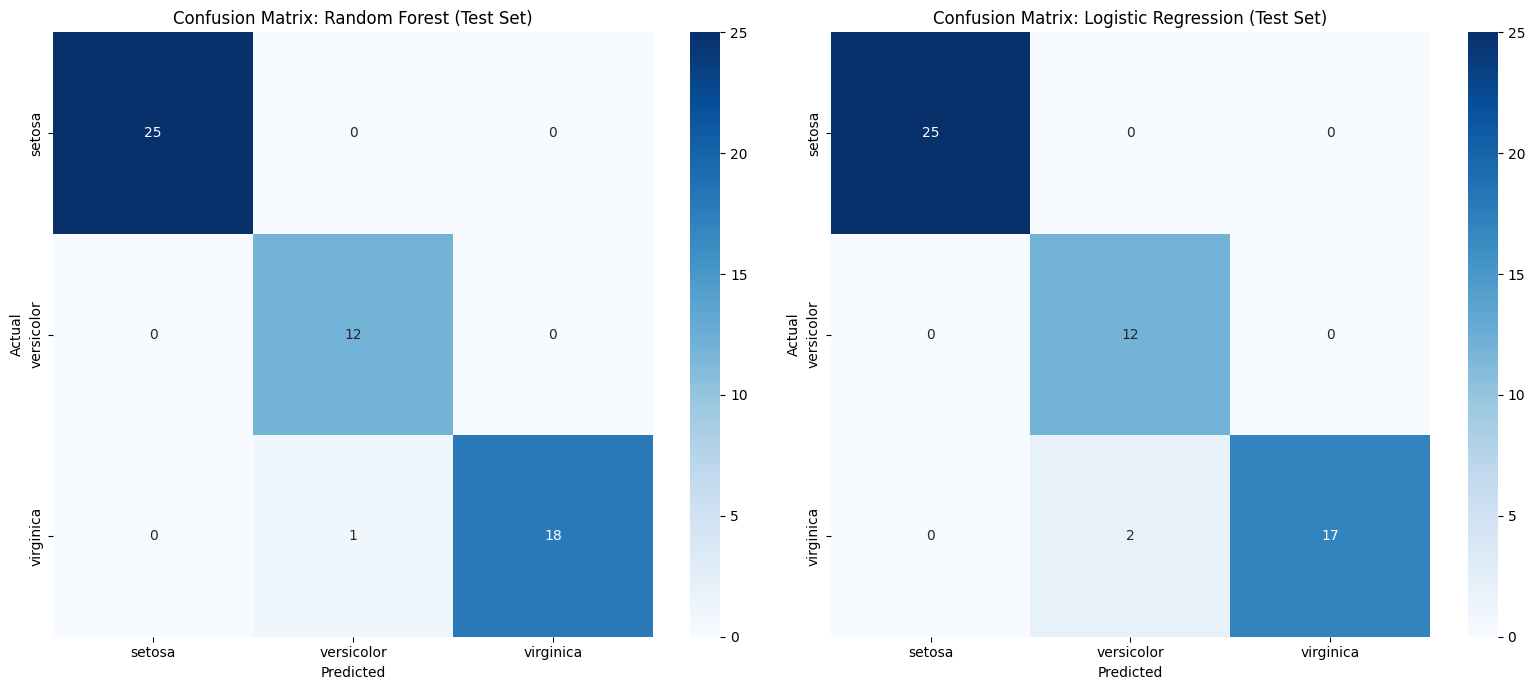

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Obtain predictions from best model (Random Forest & Logistic Regression)
pred_RF = RFmodel.transform(test_data).select('label', 'prediction').toPandas()
pred_LR = LRmodel.transform(test_data).select('label', 'prediction').toPandas()

#Forms the matrix
CM_RF = confusion_matrix(pred_RF['label'], pred_RF['prediction'])
CM_LR = confusion_matrix(pred_LR['label'], pred_LR['prediction'])

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Confusion Matrix for Random Forest
sns.heatmap(CM_RF, annot=True, fmt='g', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix: Random Forest (Test Set)')

# Plot Confusion Matrix for Logistic Regression
sns.heatmap(CM_LR, annot=True, fmt='g', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix: Logistic Regression (Test Set)')

plt.tight_layout()
plt.show()

While both models perform well, the Random Forest model outperforms by making one fewer misclassification on Virginica class. This aligns with the higher accuracy score of Random Forest compared to Logistic Regression, despite the smaller gap demonstrated between training accuracy and test accuracy in Logistic Regression.